# Week-1

# Linear Regression Example using tensorflow
Linear regression implementation with TensorFlow v2 library.

This example is using a low-level approach to better understand all mechanics behind the training process.


In [1]:
import tensorflow as tf 
import matplotlib.pyplot as plt
import numpy as np
rng = np.random

In [2]:
learning_rate = 0.01
training_steps = 1000
display_step = 50 

#### Just run the next cell using 'Ctrl' + 'Enter'

In [3]:
# Training Data.

X = np.array([3.3,4.4,5.5,6.71,6.93,4.168,9.779,6.182,7.59,2.167,
              7.042,10.791,5.313,7.997,5.654,9.27,3.1])

Y = np.array([1.7,2.76,2.09,3.19,1.694,1.573,3.366,2.596,2.53,1.221,
              2.827,3.465,1.65,2.904,2.42,2.94,1.3])

n_samples = X.shape[0]

In [4]:
print(X, '\n', X.shape) 

[ 3.3    4.4    5.5    6.71   6.93   4.168  9.779  6.182  7.59   2.167
  7.042 10.791  5.313  7.997  5.654  9.27   3.1  ] 
 (17,)


In [5]:
print(Y, '\n' , Y.shape)

[1.7   2.76  2.09  3.19  1.694 1.573 3.366 2.596 2.53  1.221 2.827 3.465
 1.65  2.904 2.42  2.94  1.3  ] 
 (17,)


In [7]:
W = tf.Variable(rng.randn(),name="weight")
b = tf.Variable(rng.randn(), name="bias")
print(W)
print(b)

<tf.Variable 'weight:0' shape=() dtype=float32, numpy=-0.31687626242637634>
<tf.Variable 'bias:0' shape=() dtype=float32, numpy=-0.3256463408470154>


In [10]:
def linear_regression(x):
    return W* x +b 

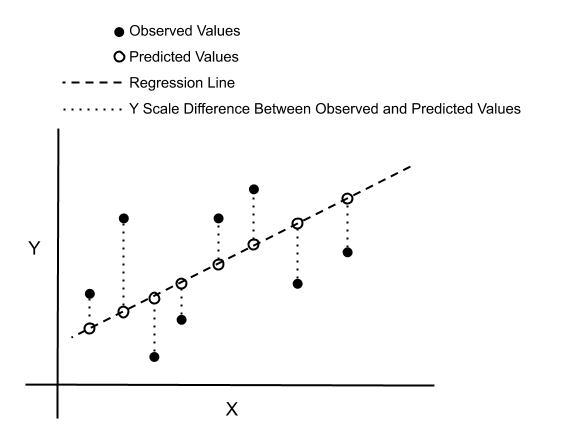

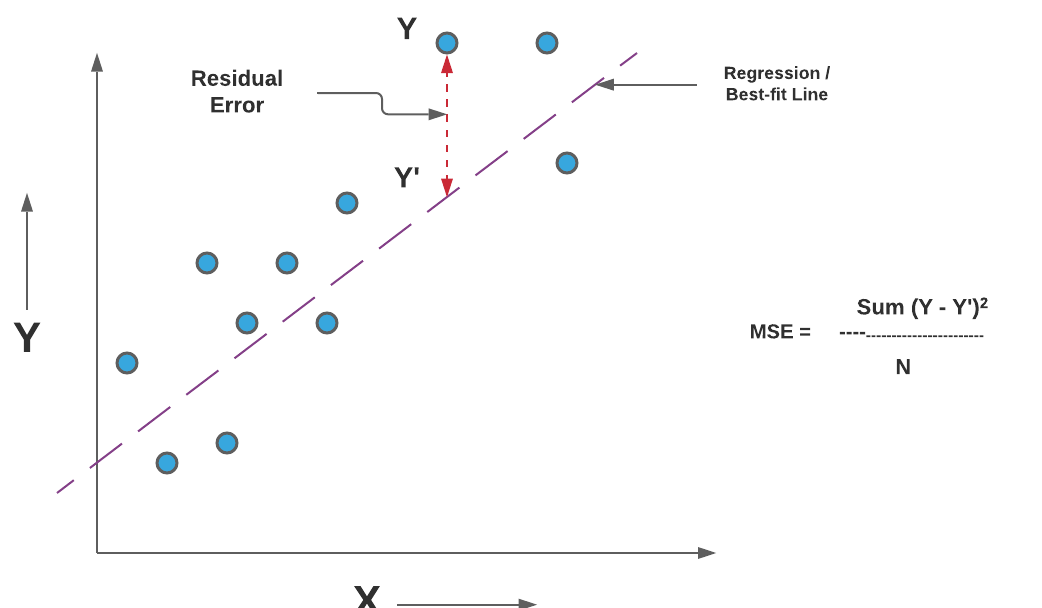

In [11]:
def mean_square(y_pred, y_true):
    return tf.reduce_sum(tf.pow(y_pred - y_true, 2) / (2 * n_samples))


In [12]:
optimizer =tf.optimizers.SGD(learning_rate) 

In [18]:
tf.optimizers.SGD?

Init signature:
tf.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.0,
    nesterov=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='SGD',
    **kwargs,
)
Docstring:     
Gradient descent (with momentum) optimizer.

Update rule for parameter `w` with gradient `g` when `momentum` is 0:

```python
w = w - learning_rate * g
```

Update rule when `momentum` is larger than 0:

```python
velocity = momentum * velocity - learning_rate * g
w = w + velocity
```

When `nesterov=True`, this rule becomes:

```python
velocity = momentum * velocity - learning_rate * g
w = w + momentum * velocity - learning_rate * g
```

Args:
    learning_rate: A float, a
        `keras.optimizers.schedules.LearningRateSchedule` instance, or
        a callable that takes no arguments and returns the actual value to


In [13]:
def run_optimization():
    with tf.GradientTape() as g:
        pred = linear_regression(X)
        loss = mean_square(pred,Y)

    gradients = g.gradient(loss, [W,b])

    optimizer.apply_gradients(zip(gradients, [W,b]))

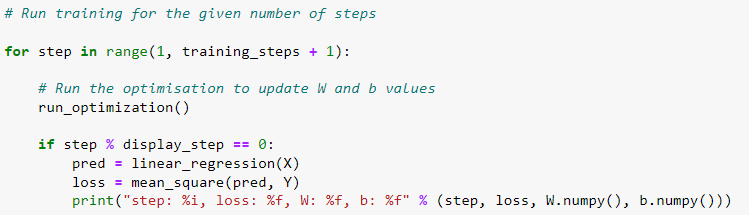

In [15]:
for step in range(1, training_steps + 1):
    run_optimization()
    
    if step % display_step == 0:
        pred = linear_regression(X)
        loss = mean_square(pred, Y)  
        print("step: %i, loss: %f, W : %f, b: %f" % 
              (step, loss.numpy(), W.numpy(), b.numpy()))

step: 50, loss: 0.127826, W : 0.379539, b: -0.107983
step: 100, loss: 0.122005, W : 0.372003, b: -0.054554
step: 150, loss: 0.116849, W : 0.364911, b: -0.004273
step: 200, loss: 0.112284, W : 0.358236, b: 0.043045
step: 250, loss: 0.108240, W : 0.351955, b: 0.087575
step: 300, loss: 0.104659, W : 0.346044, b: 0.129481
step: 350, loss: 0.101487, W : 0.340482, b: 0.168918
step: 400, loss: 0.098679, W : 0.335247, b: 0.206031
step: 450, loss: 0.096191, W : 0.330320, b: 0.240958
step: 500, loss: 0.093988, W : 0.325684, b: 0.273827
step: 550, loss: 0.092037, W : 0.321321, b: 0.304759
step: 600, loss: 0.090309, W : 0.317215, b: 0.333868
step: 650, loss: 0.088779, W : 0.313351, b: 0.361263
step: 700, loss: 0.087424, W : 0.309715, b: 0.387043
step: 750, loss: 0.086223, W : 0.306292, b: 0.411304
step: 800, loss: 0.085160, W : 0.303072, b: 0.434136
step: 850, loss: 0.084219, W : 0.300041, b: 0.455622
step: 900, loss: 0.083385, W : 0.297189, b: 0.475843
step: 950, loss: 0.082647, W : 0.294505, b: 

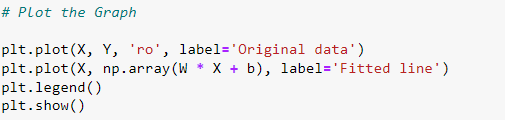

C:\Users\Madushan Pro\AppData\Local\Temp\ipykernel_26060\1549442940.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  plt.plot(X,Y, 'ro', label='Original data',color = 'green')


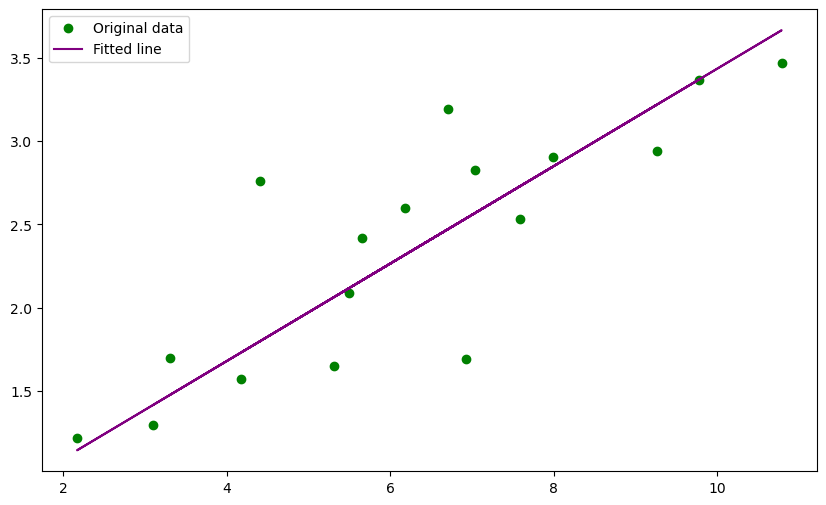

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(X,Y, 'ro', label='Original data',color = 'green')
plt.plot(X,np.array(W*X+b),label='Fitted line', color = 'purple')
plt.legend()
plt.show()

# Lab Logbook requirements: 
### Please make sure to document the following in your Lablogbook:

Include an image of the generated graph depicting the original data and the fitted line for linear regression. Modify the appearance of the graph by adjusting its color or size. Copy the figure and paste it directly into your logbook. Refrain from taking a snapshot; instead, right-click and copy the graph to your lab logbook. Ensure that no code or other information is added to the logbook and that only required graph is present.  

#### Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.